In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  

catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[2].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = (catalog.open_dataset(id=catalog.Items[1].id)).isel(t = 0, drop = True)
config = config.rename({'z': 'nav_lev'})
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt = NEMODataTree.from_datasets(datasets = datasets)



            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

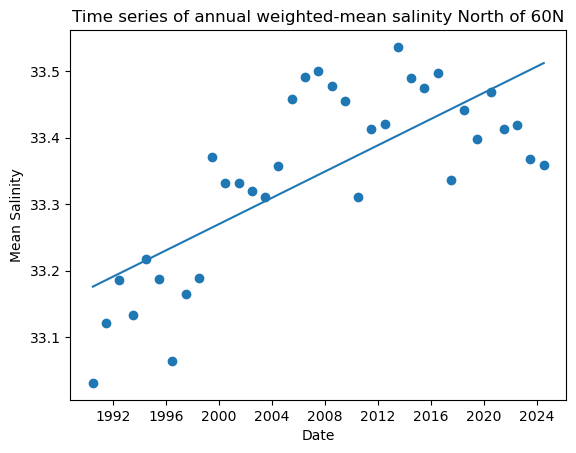

<Figure size 640x480 with 0 Axes>

In [2]:
## North of 60N

weighted_mean = dt.masked_statistic(grid='/gridT', var='sos_abs', lon_poly = [-80.0, 0.0, 0.0, -80.0, -80.0], lat_poly = [60.0, 60.0, 80.0, 80.0, 60.0], statistic="weighted_mean", dims=["i", "j"])

fig, ax = plt.subplots()
ax.scatter(weighted_mean['time_counter'], weighted_mean.values)
ax.set_xlabel('Date')
ax.set_ylabel('Mean Salinity')
ax.set_title('Time series of annual weighted-mean salinity North of 60N')

z = np.polyfit(weighted_mean['time_counter'].dt.year, weighted_mean.values, 1)
slope, intercept = z
line = slope * weighted_mean['time_counter'].dt.year + intercept

ax.plot(weighted_mean['time_counter'], line)
plt.show()
plt.savefig('60-80N salinity.png')

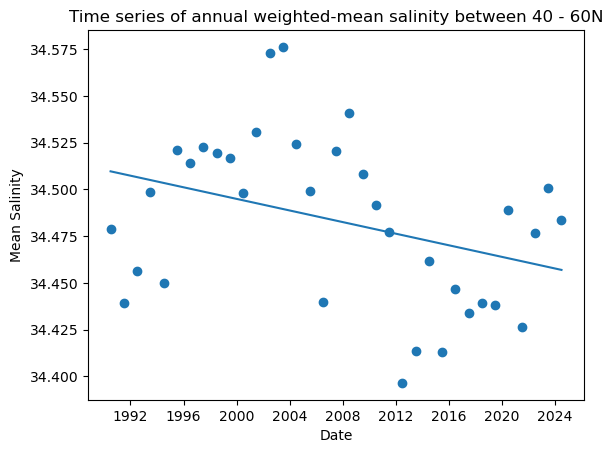

<Figure size 640x480 with 0 Axes>

In [4]:
### Now conside subpolar North Atlantic 

weighted_mean = dt.masked_statistic(grid='/gridT', var='sos_abs', lon_poly = [-80.0, 0.0, 0.0, -80.0, -80.0], lat_poly = [40.0, 40.0, 60.0, 60.0, 40.0], statistic="weighted_mean", dims=["i", "j"])

fig, ax = plt.subplots()
ax.scatter(weighted_mean['time_counter'], weighted_mean.values)
ax.set_xlabel('Date')
ax.set_ylabel('Mean Salinity')
ax.set_title('Time series of annual weighted-mean salinity between 40 - 60N')

z = np.polyfit(weighted_mean['time_counter'].dt.year, weighted_mean.values, 1)
slope, intercept = z
line = slope * weighted_mean['time_counter'].dt.year + intercept

ax.plot(weighted_mean['time_counter'], line)
plt.show()
plt.savefig('40-60N salinity.png')

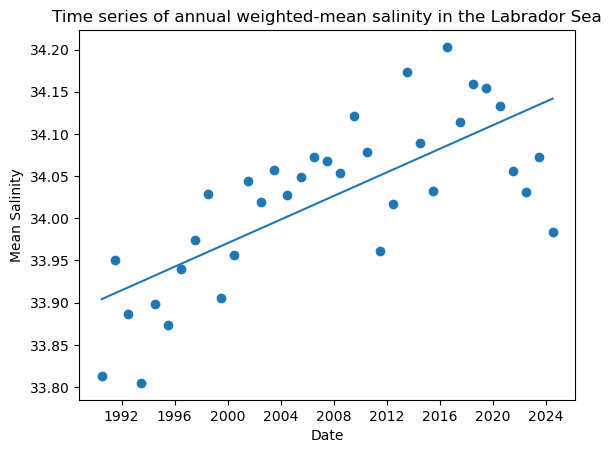

<Figure size 640x480 with 0 Axes>

In [7]:
## Labrador Sea

weighted_mean = dt.masked_statistic(grid='/gridT', var='sos_abs', lon_poly = [-65.5, -55.3, -45.2, -54.5, -65.5], lat_poly = [60.3, 52.5, 57.3, 66.5, 60.3], statistic="weighted_mean", dims=["i", "j"])

fig, ax = plt.subplots()
ax.scatter(weighted_mean['time_counter'], weighted_mean.values)
ax.set_xlabel('Date')
ax.set_ylabel('Mean Salinity')
ax.set_title('Time series of annual weighted-mean salinity in the Labrador Sea')

z = np.polyfit(weighted_mean['time_counter'].dt.year, weighted_mean.values, 1)
slope, intercept = z
line = slope * weighted_mean['time_counter'].dt.year + intercept

ax.plot(weighted_mean['time_counter'], line)
plt.show()
plt.savefig('Labrador Sea Salinity.png')